# 用户行为与消费习惯分析

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
# 解决中文显示
plt.rcParams["font.sans-serif"] = ["SimHei"]
# 解决负号乱码
plt.rcParams["axes.unicode_minus"] = False

## 数据清洗

In [3]:
df=pd.read_csv('客户行为与消费习惯的数据集.csv')
df

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,38.0,Female,USA,Los Angeles,10.0,10.0,35.8,8.8,51.2,3.0,...,9.2,5.0,1.0,20.7,25.2,1.0,2365.98,3499.0,0,Q2
49996,37.0,Male,USA,Chicago,1.4,21.0,32.4,9.6,32.5,2.0,...,17.6,5.0,3.0,38.6,12.1,4.0,1293.60,3154.0,0,Q3
49997,44.0,Female,USA,Phoenix,2.8,19.0,40.3,10.4,50.6,1.0,...,25.2,4.0,6.0,59.9,NaN,1.0,1655.28,1622.0,0,Q1
49998,41.0,Female,USA,Chicago,2.9,17.0,29.9,10.1,60.8,1.0,...,34.6,5.0,2.0,NaN,14.1,3.0,1286.11,2634.0,0,Q2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null 

In [5]:
df.isnull().count()
df.isnull().mean()*100
# df.isnull().sum()/len(df)
# df.isnull().sum()

Age                               4.990
Gender                            0.000
Country                           0.000
City                              0.000
Membership_Years                  0.000
Login_Frequency                   0.000
Session_Duration_Avg              6.798
Pages_Per_Session                 6.000
Cart_Abandonment_Rate             0.000
Wishlist_Items                    8.000
Total_Purchases                   0.000
Average_Order_Value               0.000
Days_Since_Last_Purchase          6.000
Discount_Usage_Rate               7.000
Returns_Rate                      8.982
Email_Open_Rate                   5.056
Customer_Service_Calls            0.336
Product_Reviews_Written           7.000
Social_Media_Engagement_Score    12.000
Mobile_App_Usage                 10.000
Payment_Method_Diversity          5.000
Lifetime_Value                    0.000
Credit_Balance                   11.000
Churned                           0.000
Signup_Quarter                    0.000


In [6]:
df.columns.value_counts()

Age                              1
Gender                           1
Country                          1
City                             1
Membership_Years                 1
Login_Frequency                  1
Session_Duration_Avg             1
Pages_Per_Session                1
Cart_Abandonment_Rate            1
Wishlist_Items                   1
Total_Purchases                  1
Average_Order_Value              1
Days_Since_Last_Purchase         1
Discount_Usage_Rate              1
Returns_Rate                     1
Email_Open_Rate                  1
Customer_Service_Calls           1
Product_Reviews_Written          1
Social_Media_Engagement_Score    1
Mobile_App_Usage                 1
Payment_Method_Diversity         1
Lifetime_Value                   1
Credit_Balance                   1
Churned                          1
Signup_Quarter                   1
Name: count, dtype: int64

In [7]:
df.columns

Index(['Age', 'Gender', 'Country', 'City', 'Membership_Years',
       'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session',
       'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases',
       'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Customer_Service_Calls', 'Product_Reviews_Written',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage',
       'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance',
       'Churned', 'Signup_Quarter'],
      dtype='object')

In [8]:
# df.dropna(how='all')
# df.dropna(thresh=3)
df=df.dropna(thresh=len(df.columns)*0.8)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49988 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47495 non-null  float64
 1   Gender                         49988 non-null  object 
 2   Country                        49988 non-null  object 
 3   City                           49988 non-null  object 
 4   Membership_Years               49988 non-null  float64
 5   Login_Frequency                49988 non-null  float64
 6   Session_Duration_Avg           46595 non-null  float64
 7   Pages_Per_Session              46992 non-null  float64
 8   Cart_Abandonment_Rate          49988 non-null  float64
 9   Wishlist_Items                 45994 non-null  float64
 10  Total_Purchases                49988 non-null  float64
 11  Average_Order_Value            49988 non-null  float64
 12  Days_Since_Last_Purchase       46993 non-null  floa

In [9]:
df[df.isnull()=='True']
df

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,38.0,Female,USA,Los Angeles,10.0,10.0,35.8,8.8,51.2,3.0,...,9.2,5.0,1.0,20.7,25.2,1.0,2365.98,3499.0,0,Q2
49996,37.0,Male,USA,Chicago,1.4,21.0,32.4,9.6,32.5,2.0,...,17.6,5.0,3.0,38.6,12.1,4.0,1293.60,3154.0,0,Q3
49997,44.0,Female,USA,Phoenix,2.8,19.0,40.3,10.4,50.6,1.0,...,25.2,4.0,6.0,59.9,NaN,1.0,1655.28,1622.0,0,Q1
49998,41.0,Female,USA,Chicago,2.9,17.0,29.9,10.1,60.8,1.0,...,34.6,5.0,2.0,NaN,14.1,3.0,1286.11,2634.0,0,Q2


In [10]:
df.duplicated().sum()

np.int64(0)

## 数据分析

### 客户画像与分群分析

#### RFM

In [11]:
rfm_data=pd.DataFrame()

In [12]:
rfm_data['r']=df['Days_Since_Last_Purchase']
rfm_data['f']=df['Total_Purchases']
rfm_data['m']=df['Lifetime_Value']
# rfm_data=rfm_data.drop(columns=['R','F','M'])
rfm_data
rfm_data = rfm_data.dropna(subset=['r', 'f', 'm']).copy()

In [13]:
# 打分
def rfm_scores(rfm_data):
    try:
        rfm_data['r_score']=pd.qcut(rfm_data['r'].rank(method='first'),5,labels=[5,4,3,2,1]).astype(int)
    except:
        rfm_data['r_score']=pd.qcut(rfm_data['r'].rank(method='first'),3,labels=[3,2,1]).astype(int)

    try:
        rfm_data['f_score']=pd.qcut(rfm_data['f'].rank(method='first'),5,labels=[5,4,3,2,1]).astype(int)
    except:
        rfm_data['f_score']=pd.qcut(rfm_data['f'].rank(method='first'),3,labels=[3,2,1]).astype(int)

    try:
        rfm_data['m_score']=pd.qcut(rfm_data['m'].rank(method='first'),5,labels=[5,4,3,2,1]).astype(int)
    except:
        rfm_data['m_score']=pd.qcut(rfm_data['m'].rank(method='first'),3,labels=[3,2,1]).astype(int)
    return rfm_data

rfm_datas=rfm_scores(rfm_data)
print(rfm_datas[['r_score','f_score','m_score']].describe())
print(rfm_datas['r_score'].value_counts().sort_index())
print(rfm_datas['f_score'].value_counts().sort_index())
print(rfm_datas['m_score'].value_counts().sort_index())


            r_score       f_score       m_score
count  46993.000000  46993.000000  46993.000000
mean       3.000000      3.000000      3.000000
std        1.414244      1.414244      1.414244
min        1.000000      1.000000      1.000000
25%        2.000000      2.000000      2.000000
50%        3.000000      3.000000      3.000000
75%        4.000000      4.000000      4.000000
max        5.000000      5.000000      5.000000
r_score
1    9399
2    9398
3    9399
4    9398
5    9399
Name: count, dtype: int64
f_score
1    9399
2    9398
3    9399
4    9398
5    9399
Name: count, dtype: int64
m_score
1    9399
2    9398
3    9399
4    9398
5    9399
Name: count, dtype: int64


In [14]:
# 客户分群
rfm_datas['rfm_socres']=rfm_datas['r_score']*100+rfm_datas['f_score']*10+rfm_datas['m_score']
rfm_datas['rfm_total']=rfm_datas['r_score']+rfm_datas['f_score']+rfm_datas['m_score']

max_score=rfm_datas[['r_score','f_score','m_score']].max().max()

# 定义客户分群函数
def classify_cunstomer(row,max_score=5):
    r,f,m=row['r_score'],row['f_score'],row['m_score']

    # 高价值：R高+F高+M高

    if r>=max_score-1 and f>=max_score-1 and m>=max_score-1:
        return '顶级高价值客户'
    elif r>=max_score-1 and f>=max_score-1:
        return '核心高价值客户'
    elif r>max_score-1 and m>max_score-1:
        return '潜力唤醒客户'

    # 潜力客户：F高或M高
    elif f>=max_score-1 or m>=max_score-1:
        return '潜力成长客户'

    # 风险客户：R低
    elif r<=2 and (f>=3 or m>=3):
        return '流失风险客户'

    # 新客户：R高但F低
    elif r>=max_score-1 and f<=2:
        return '新客户'

    # 沉睡客户
    elif r<=2:
        return '沉睡客户'
    else:
        return '一般客户'


In [15]:
rfm_data['Customer_Segment']=rfm_data.apply(classify_cunstomer,axis=1)

# 统计分群结果
segment_stats=rfm_data['Customer_Segment'].value_counts()
# segment_stats
for segment,count in segment_stats.items():
    print(f"{segment}:{count} ({count/len(rfm_data)*100:.1f}%)")

潜力成长客户:15882 (33.8%)
一般客户:7286 (15.5%)
新客户:6765 (14.4%)
顶级高价值客户:5557 (11.8%)
沉睡客户:5408 (11.5%)
流失风险客户:3969 (8.4%)
核心高价值客户:1940 (4.1%)
潜力唤醒客户:186 (0.4%)


### 高价值客户识别与特征分析

In [16]:
# 定义高价值客户（综合分前20%或特定分群）
high_value_threshold=rfm_data['rfm_total'].quantile(0.8)
# high_value_threshold
high_value_customers=rfm_data[rfm_data['rfm_total']>=high_value_threshold]
# high_value_customers

# 或使用分群筛选
high_value_segments=['顶级高价值客户','核心高价值客户','潜力唤醒客户']
high_value_customers2=rfm_data[rfm_data['Customer_Segment'].isin(high_value_segments)]

print('=== 高价值客户识别 ===')
print(f'方法1(RFM总分前20%)：{len(high_value_customers)}人({len(high_value_customers)/len(rfm_data)*100:.1f}%)')
print(f'方法2(特定分群): {len(high_value_customers2)} 人 ({len(high_value_customers2)/len(rfm_data)*100:.1f}%)')

# ============ 导出高价值客户 ============
high_value_customers.to_csv('high_value_customers.csv', encoding='utf-8-sig')
print(f" 高价值客户(RFM总分前20%)已导出: high_value_customers.csv ({len(high_value_customers)}人)")
high_value_customers2.to_csv('high_value_customers2.csv', encoding='utf-8-sig')
print(f" 高价值客户(特定分群)已导出: high_value_customers2.csv ({len(high_value_customers2)}人)")

=== 高价值客户识别 ===
方法1(RFM总分前20%)：10496人(22.3%)
方法2(特定分群): 7683 人 (16.3%)
 高价值客户(RFM总分前20%)已导出: high_value_customers.csv (10496人)
 高价值客户(特定分群)已导出: high_value_customers2.csv (7683人)


In [17]:
# 高价值客户特征对比
high_value_idx=high_value_customers.index
normal_idx=rfm_data[~rfm_data.index.isin(high_value_idx)].index
print(f'\n=== 高价值客户 vs 普通客户特征对比 ===')
features_to_compare=['Login_Frequency','Average_Order_Value','Discount_Usage_Rate',
                     'customer_Service_Calls','Email_Open_Rate','Wishlist_Items']
for feature in features_to_compare:
    if feature in df.columns:
        hv_mean=df.loc[high_value_idx,feature].mean()
        normal_mean=df.loc[normal_idx,feature].mean()
        diff_pct=((hv_mean-normal_mean)/normal_mean)*100
        print(f'{feature}: 高价值={hv_mean:.2f} | 普通={normal_mean:.2f} | 差异={diff_pct:+.1f}%')


=== 高价值客户 vs 普通客户特征对比 ===
Login_Frequency: 高价值=6.29 | 普通=13.17 | 差异=-52.3%
Average_Order_Value: 高价值=107.84 | 普通=127.31 | 差异=-15.3%
Discount_Usage_Rate: 高价值=41.36 | 普通=42.14 | 差异=-1.9%
Email_Open_Rate: 高价值=11.49 | 普通=23.52 | 差异=-51.1%
Wishlist_Items: 高价值=2.19 | 普通=4.91 | 差异=-55.3%


### 可视化分析

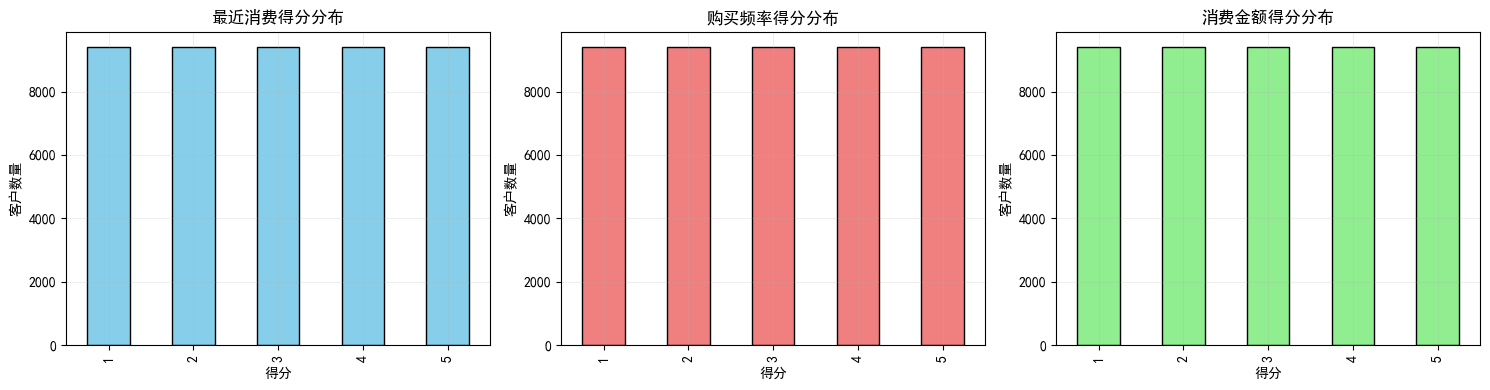

In [18]:
# 1.RFM分数分布图
fig,ax=plt.subplots(1,3,figsize=(15,4))
score_cols=['r_score','f_score','m_score']
titles=['最近消费得分分布','购买频率得分分布','消费金额得分分布']
colors=['skyblue','lightcoral','lightgreen']
for i,(col,title,color) in enumerate(zip(score_cols,titles,colors)):
    rfm_data[col].value_counts().sort_index().plot(kind='bar',ax=ax[i],color=color,edgecolor='black')
    ax[i].set_title(title)
    ax[i].set_xlabel('得分')
    ax[i].set_ylabel('客户数量')
    ax[i].grid(True,alpha=0.3)

plt.tight_layout()
plt.show()

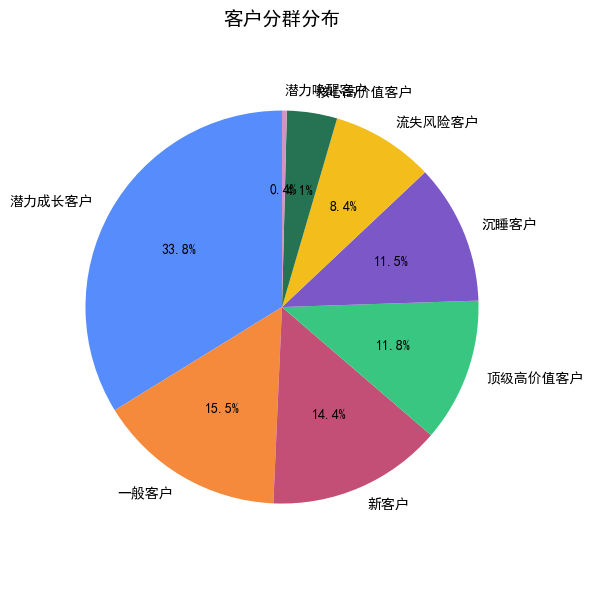

In [19]:
#2.客户分群占比
plt.figure(figsize=(6,6))
plt.pie(segment_stats,labels=segment_stats.index,autopct='%1.1f%%',startangle=90)
plt.title('客户分群分布',fontsize=14)
plt.axis('equal')
plt.tight_layout()
plt.show()

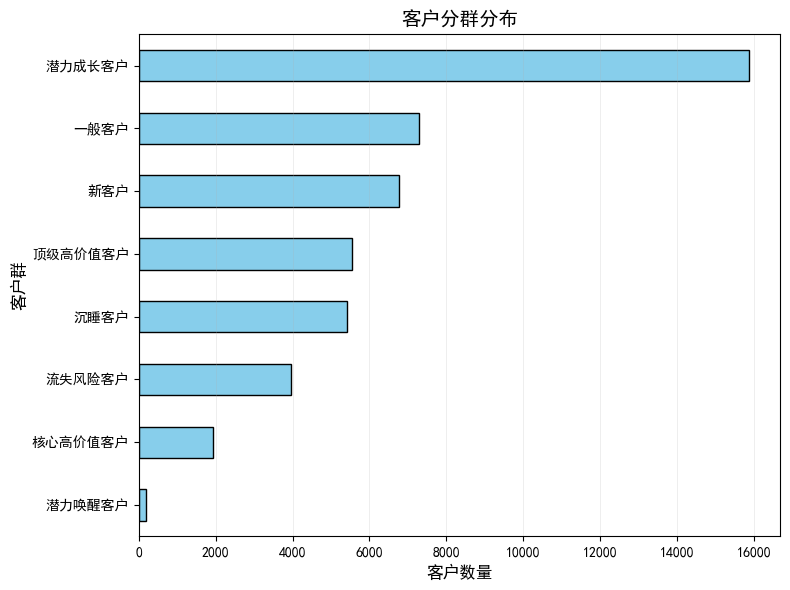

In [20]:
plt.figure(figsize=(8,6))
segment_stats.sort_values().plot(kind='barh',color='skyblue',edgecolor='black')
plt.title('客户分群分布',fontsize=14)
plt.xlabel('客户数量',fontsize=12)
plt.ylabel('客户群',fontsize=12)
plt.grid(True,alpha=0.3,axis='x')
plt.tight_layout()
plt.show()

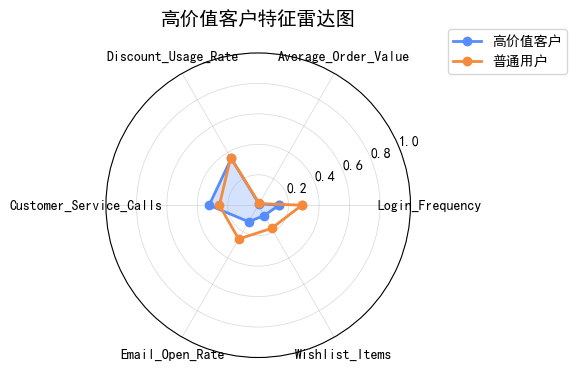

In [21]:
#3.高价值客户雷达图
from math import pi

features=['Login_Frequency','Average_Order_Value','Discount_Usage_Rate',
         'Customer_Service_Calls','Email_Open_Rate','Wishlist_Items']

#计算各组均值
hv_means=[df.loc[high_value_idx,f].mean() for f in features]
normal_means=[df.loc[normal_idx,f].mean() for f in features]

#归一化
max_vals=[df[f].max() for f in features]
hv_normalized=[hv_means[i]/max_vals[i] for i in range(len(features))]
normal_normalized=[normal_means[i]/max_vals[i] for i in range(len(features))]

#绘制雷达图
angles=[n/len(features)*2*pi for n in range(len(features))]
angles+=angles[:1]

fig,ax=plt.subplots(figsize=(6,6),subplot_kw=dict(projection='polar'))
ax.plot(angles,hv_normalized+hv_normalized[:1],'o-',linewidth=2,label='高价值客户')
ax.plot(angles,normal_normalized+normal_normalized[:1],'o-',linewidth=2,label='普通用户')
ax.fill(angles,hv_normalized+hv_normalized[:1],alpha=0.25)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(features,size=10)
ax.set_ylim(0,1)
ax.set_title('高价值客户特征雷达图',size=14,pad=20)
ax.legend(loc='upper left',bbox_to_anchor=(1.1,1.1))
plt.tight_layout()
plt.show()

In [22]:
# 生成业务建议报告
print("\n" + "="*60)
print("RFM模型分析报告 - 业务建议")
print("="*60)

# 不同客户群的针对性策略
strategies = {
    '⭐ 顶级高价值客户': '1. 专属客户经理服务\n2. 优先体验新品\n3. 生日/节日定制礼品\n4. VIP专属折扣',
    '💎 核心高价值客户': '1. 升级会员等级激励\n2. 邀请加入忠诚度计划\n3. 积分加倍活动\n4. 个性化推荐',
    '💰 潜力唤醒客户': '1. 高价值商品推荐\n2. 限时优惠券\n3. 专属客服跟进',
    '📈 潜力成长客户': '1. 促销活动推送\n2. 交叉销售推荐\n3. 会员升级引导',
    '⚠️ 流失风险客户': '1. 发送召回优惠券\n2. 满意度调查\n3. 邮件/短信提醒',
    '🆕 新客户': '1. 欢迎优惠券\n2. 使用教程推送\n3. 首单返现活动',
    '😴 沉睡客户': '1. 大力度召回优惠\n2. 产品更新通知\n3. 问卷调查',
    '📊 一般客户': '1. 常规营销推送\n2. 自动化邮件营销\n3. 标准服务'
}

for segment, strategy in strategies.items():
    count = segment_stats.get(segment, 0)
    if count > 0:
        print(f"\n【{segment}】({count}人, {count/len(rfm_data)*100:.1f}%)")
        print(f"建议策略：\n{strategy}")


RFM模型分析报告 - 业务建议


In [23]:
# 合并原始数据和RFM结果
final_df = df.copy()
final_df['r_score'] = rfm_data['r_score']
final_df['f_score'] = rfm_data['f_score']
final_df['m_score'] = rfm_data['m_score']
final_df['rfm_total'] = rfm_data['rfm_total']
final_df['Customer_Segment'] = rfm_data['Customer_Segment']

# ============ 导出分群汇总 ============
# 使用 agg 配合字典
summary = final_df.groupby('Customer_Segment').agg({
    'Lifetime_Value': ['count', 'mean', 'sum'],
    'Total_Purchases': ['mean', 'sum'],
    'Days_Since_Last_Purchase': 'mean',
    'Average_Order_Value': 'mean'
}).round(2)

# 简化列名
summary.columns = ['客户数', '平均LTV', '总LTV',
                   '平均购买次数', '总购买次数',
                   '最近购买天数', '平均订单金额']

# 按客户数排序
summary = summary.sort_values('客户数', ascending=False)

print("\n========== 客户分群汇总 ==========")
print(summary)



========== 客户分群汇总 ==========
                    客户数    平均LTV         总LTV  平均购买次数     总购买次数  最近购买天数  \
Customer_Segment                                                          
潜力成长客户            15882   829.06  13167080.35    9.29  147511.4   40.46   
一般客户               7286  1925.47  14028984.81   15.71  114453.3   16.02   
新客户                6765  2214.19  14978980.75   19.68  133104.7    7.10   
顶级高价值客户            5557   621.37   3452935.84    6.63   36854.1    7.07   
沉睡客户               5408  2447.84  13237893.05   20.06  108487.1   58.02   
流失风险客户             3969  1518.98   6028820.14   14.20   56364.5   56.76   
核心高价值客户            1940  1422.47   2759585.97    8.75   16966.6    7.08   
潜力唤醒客户              186   594.54    110584.76   13.84    2573.9    3.53   

                  平均订单金额  
Customer_Segment          
潜力成长客户            108.42  
一般客户              135.79  
新客户               132.40  
顶级高价值客户           106.05  
沉睡客户              139.35  
流失风险客户            124.15  
核心高

In [24]:
# 导出customer_segment_summary.csv结果
summary.to_csv('customer_segment_summary.csv', encoding='utf-8-sig')
print(f"\n customer_segment_summary.csv数据包含 {len(summary)} 行，{len(summary.columns)} 列")


 customer_segment_summary.csv数据包含 8 行，7 列


In [25]:
#查看RFM结果
print(final_df)

        Age  Gender Country         City  Membership_Years  Login_Frequency  \
0      43.0    Male  France    Marseille               2.9             14.0   
1      36.0    Male      UK   Manchester               1.6             15.0   
2      45.0  Female  Canada    Vancouver               2.9             10.0   
3      56.0  Female     USA     New York               2.6             10.0   
4      35.0    Male   India        Delhi               3.1             29.0   
...     ...     ...     ...          ...               ...              ...   
49995  38.0  Female     USA  Los Angeles              10.0             10.0   
49996  37.0    Male     USA      Chicago               1.4             21.0   
49997  44.0  Female     USA      Phoenix               2.8             19.0   
49998  41.0  Female     USA      Chicago               2.9             17.0   
49999  56.0    Male      UK        Leeds               2.2              2.0   

       Session_Duration_Avg  Pages_Per_Session  Car

In [26]:
#导出完整的RFM结果
final_df.to_csv('rfm_analysis_full.csv', encoding='utf-8-sig')
print(f"\n rfm_analysis_full.csv数据包含 {len(final_df)} 行，{len(final_df.columns)} 列")


 rfm_analysis_full.csv数据包含 49988 行，30 列
